# Week 3 Assignment



## Import Libraries
 Importing all required libraries for data handling, visualization, scaling, clustering, PCA and evaluation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN,  AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Section 2: Load Dataset
Load the country dataset and take a quick look at its structure

In [3]:
df=pd.read_csv("Country-data.csv")
df.head()
print("Shape:", df.shape)
df.info()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


# Data Cleaning
Cleaning the dataset: strip column name spaces, drop duplicate rows,
convert relevant columns to numeric, and fill missing values with median
Remove extra spaces

In [37]:
df.columns = df.columns.str.strip()

#Remove duplicates
df.drop_duplicates(inplace=True)

#Check missing values
print(df.isnull().sum())

#Convert numerical columns
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

#Fill missing values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)



country                   0
child_mort                0
exports                   0
health                    0
imports                   0
income                    0
inflation                 0
life_expec                0
total_fer                 0
gdpp                      0
KMeans_cluster            0
DBSCAN_Cluster            0
Hierarchical_Cluster      0
Cluster_Label           167
dtype: int64


In [38]:
# Re-check missing values after cleaning to confirm everything is handled
print(df.isnull().sum())

country                   0
child_mort                0
exports                   0
health                    0
imports                   0
income                    0
inflation                 0
life_expec                0
total_fer                 0
gdpp                      0
KMeans_cluster            0
DBSCAN_Cluster            0
Hierarchical_Cluster      0
Cluster_Label           167
dtype: int64


# Exploratory Data Analysis

In [39]:
# Quick statistical summary of all numeric columns
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cluster,DBSCAN_Cluster,Hierarchical_Cluster,Cluster_Label
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,0.0
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689,1.287425,-0.179641,0.958084,NaN
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809,0.799863,0.385042,0.604733,NaN
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000,0.000000,-1.000000,0.000000,NaN
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000,1.000000,0.000000,1.000000,NaN
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000,2.000000,0.000000,1.000000,NaN
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000,2.000000,0.000000,1.000000,NaN
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000,2.000000,0.000000,2.000000,NaN


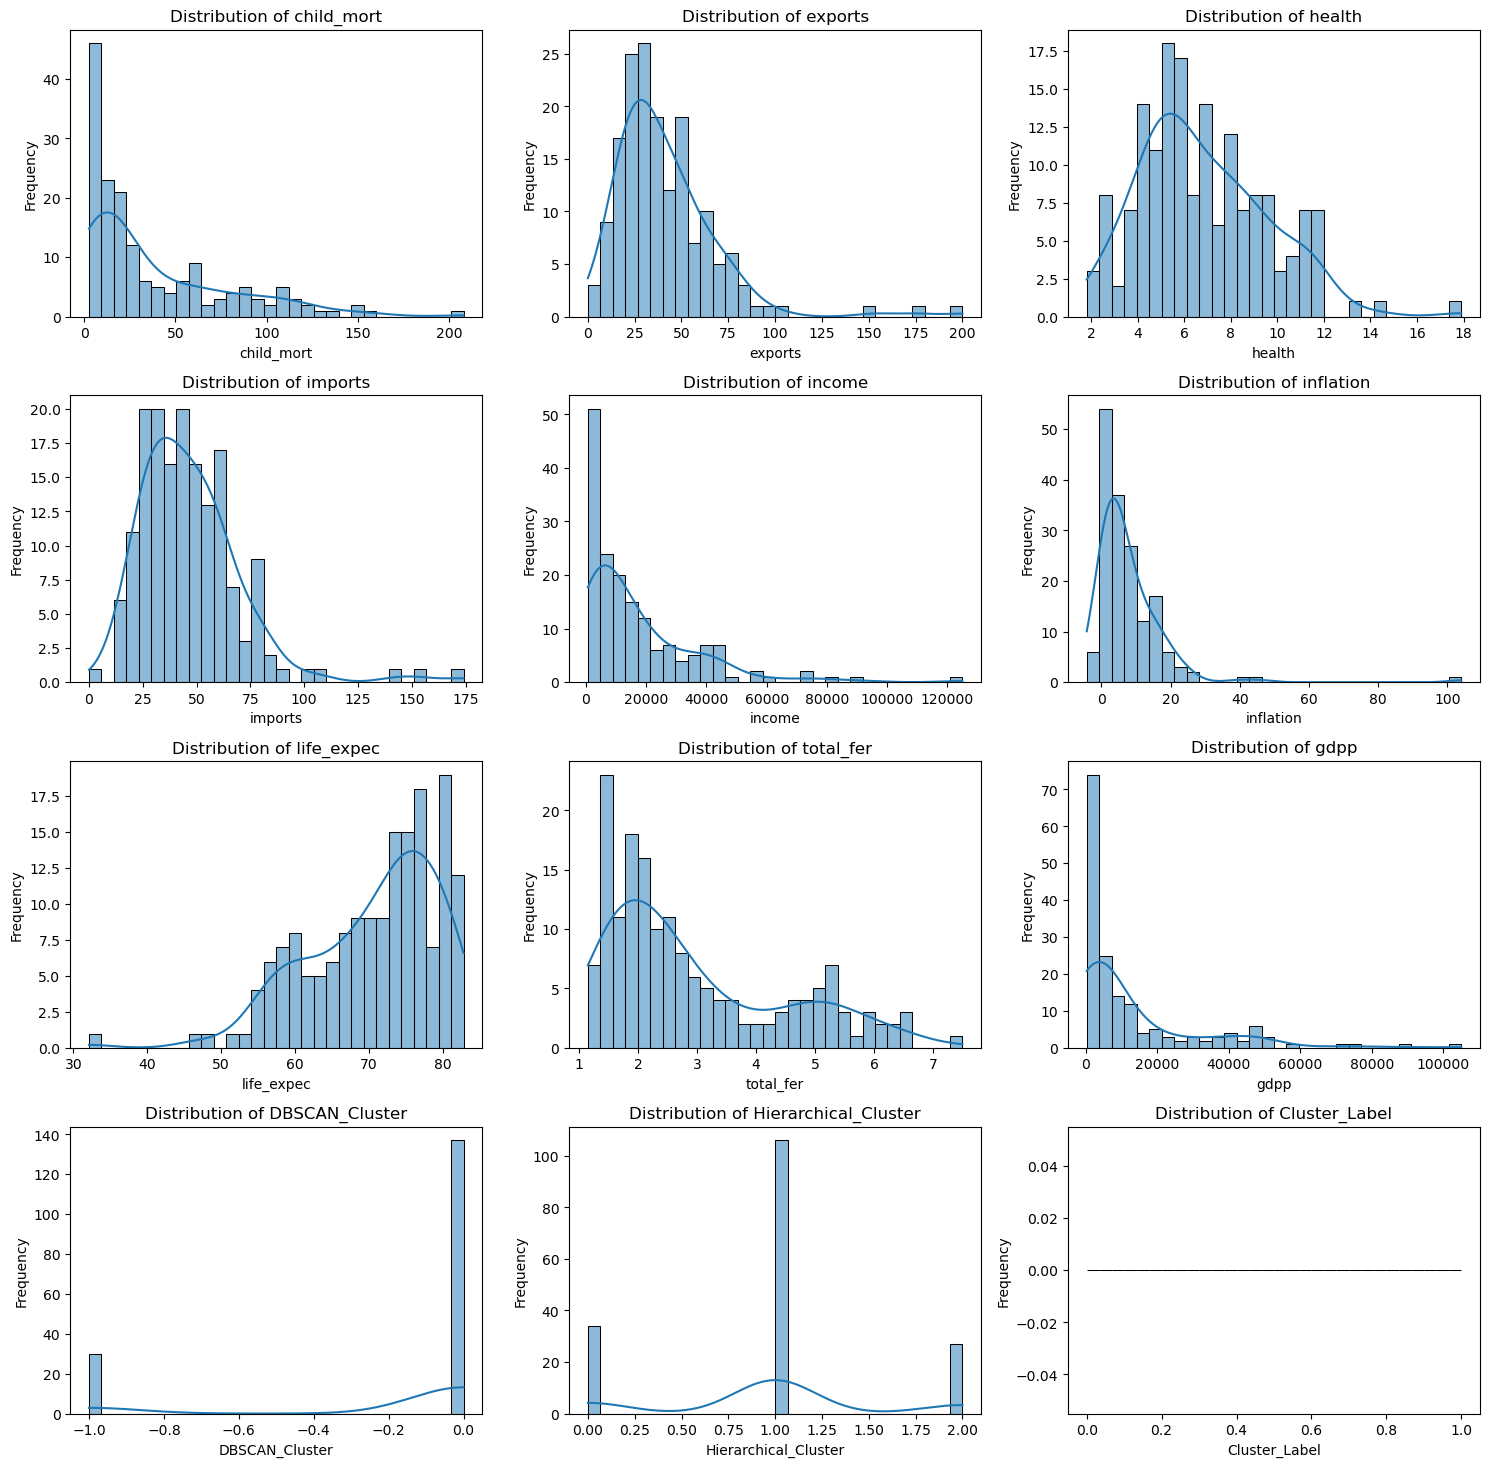

In [46]:
# Plot distribution (histogram + KDE) for every numeric column side by side
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set a single large figure size for the entire grid layout
plt.figure(figsize=(15, 18)) 

for i, col in enumerate(num_cols):
    #Arrange plots in a grid of 5 rows and 3 columns
    plt.subplot(5, 3, i + 1) 
    
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

#  Adjust layout to prevent plots from overlapping
plt.tight_layout()
plt.show()

**Correlation Heatmap**


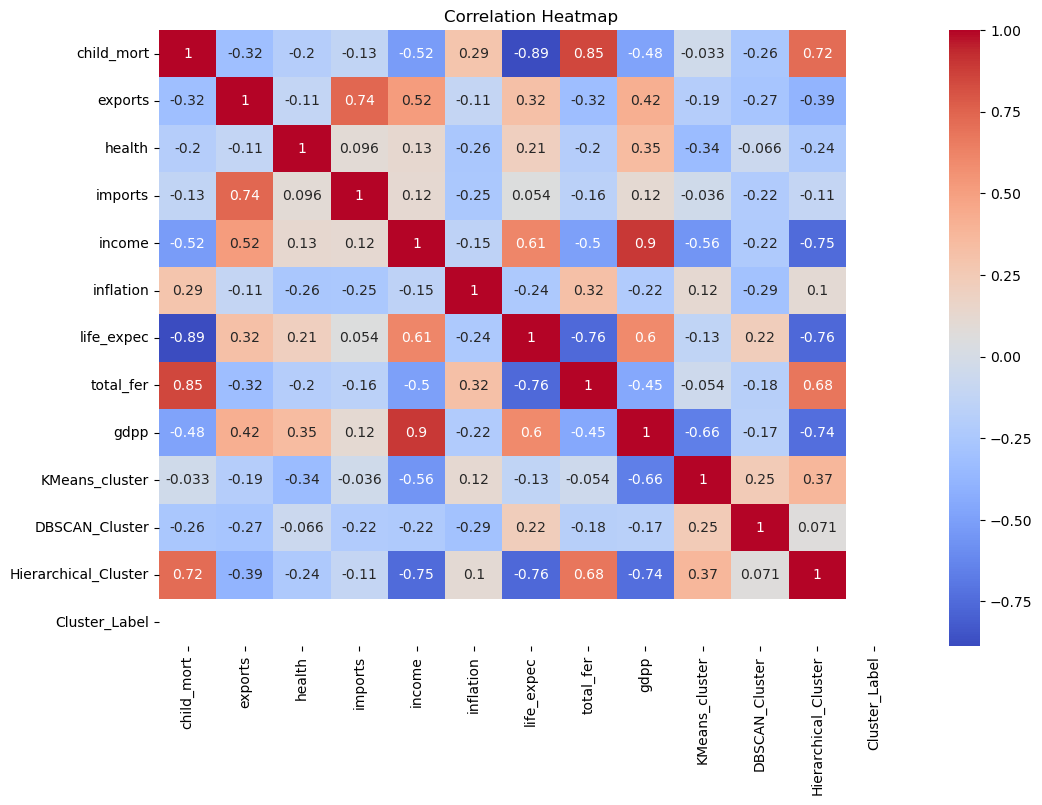

In [48]:
# Visualize correlation between all numeric features using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insights from Correlation Heatmap

1) Strongest Economic Link: Income and GDP per Capita share a very strong positive correlation, moving closely together.

2) Wealth Dynamic Duo: Higher Income and GDP per Capita are directly tied to an increased Life Expectancy.

3) Child Mortality Risk: Lower Income and shorter Life Expectancy are both associated with a higher rate of Child Mortality.



# Feature Selection

In [9]:
# Separate the country names and keep only numeric features for modeling
# Store country names separately
countries = df['country']
#Remove country column
X = df.drop('country', axis=1)

# Feature Scaling


In [49]:
# Scale all features to the same range so clustering isn't biased by magnitude
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# Elbow Method

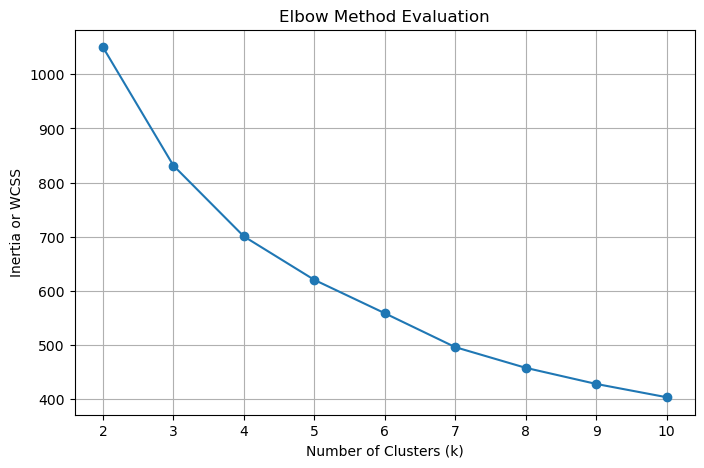

In [50]:
# Elbow method: try k from 2 to 10 and record inertia to find the best k
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia or WCSS")
plt.title("Elbow Method Evaluation")
plt.grid(True)
plt.show()


# K-Means model



In [52]:
# Fit K-Means with k=3 and check clustering quality using silhouette score
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, kmeans_labels)
df['KMeans_cluster'] = kmeans_labels
print(f"Silhouette Score for k=3 is {score:.4f}")
df.head()

Silhouette Score for k=3 is 0.2833


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cluster,DBSCAN_Cluster,Hierarchical_Cluster,Cluster_Label
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0,2,NaN
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0,1,NaN
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0,1,NaN
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1,1,NaN
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0,1,NaN


# DBSCAN

In [53]:
# Apply DBSCAN to detect dense clusters and noise points
dbscan = DBSCAN(eps=1.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())

print(f"\nNoise points: {(df['DBSCAN_Cluster'] == -1).sum()}")

# Calculate silhouette score only if there are at least 2 clusters
labels = df['DBSCAN_Cluster']

if len(np.unique(labels)) > 1:
    print(f"DBSCAN Silhouette Score: {silhouette_score(X_scaled, labels):.4f}")
else:
    print("Silhouette Score cannot be calculated (only one cluster found).")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

Noise points: 30
DBSCAN Silhouette Score: 0.2883


# Heirarchical clustering

In [54]:
# Apply Hierarchical (Agglomerative) clustering and compare with K-Means
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hc_labels
print(f"Hierarchical Silhouette Score: {silhouette_score(X_scaled, hc_labels):.4f}\n")

Hierarchical Silhouette Score: 0.2456



# PCA

In [15]:
# Reduce data to 2D using PCA for visualization purposes
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions to 2 principal components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(data=pca_data,columns=['PC1', 'PC2'])

# Add K-Means cluster labels
pca_df['Cluster'] = kmeans_labels

# PCA Scatter Plot




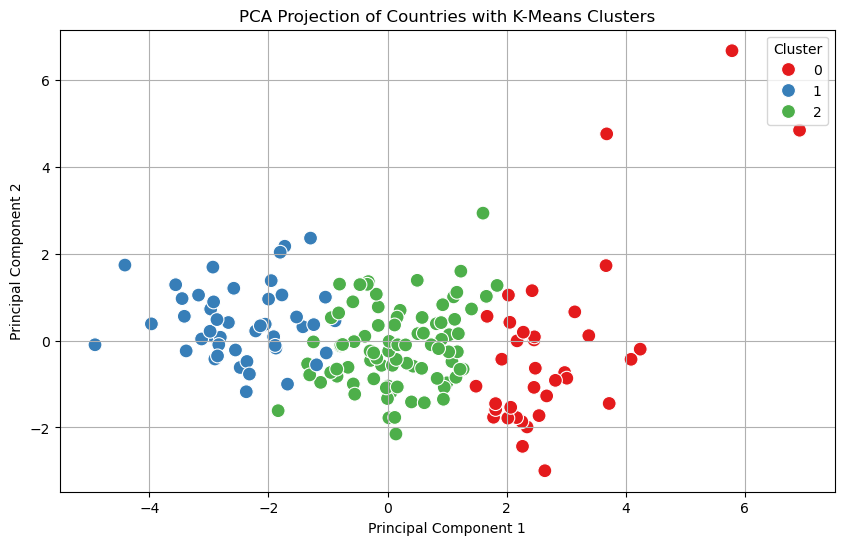

In [55]:
# Scatter plot of countries in PCA space, colored by K-Means cluster
plt.figure(figsize=(10,6))

sns.scatterplot(x='PC1',y='PC2',hue='Cluster',palette='Set1',data=pca_df,s=100)

plt.title('PCA Projection of Countries with K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Cluster Analysis and Interpretation

In [56]:
# Compute average feature values for each cluster to understand their profile
# Cluster Profiling
cluster_profile = df.groupby('KMeans_cluster').mean(numeric_only=True)
print(cluster_profile)

                child_mort    exports    health    imports        income  \
KMeans_cluster                                                             
0                 5.000000  58.738889  8.807778  51.491667  45672.222222   
1                92.961702  29.151277  6.388511  42.323404   3942.404255   
2                21.927381  40.243917  6.200952  47.473404  12305.595238   

                inflation  life_expec  total_fer          gdpp  \
KMeans_cluster                                                   
0                2.671250   80.127778   1.752778  42494.444444   
1               12.019681   59.187234   5.008085   1922.382979   
2                7.600905   72.814286   2.307500   6486.452381   

                DBSCAN_Cluster  Hierarchical_Cluster  Cluster_Label  
KMeans_cluster                                                       
0                    -0.250000              0.138889            NaN  
1                    -0.340426              1.574468            NaN  
2       

In [57]:
# Map numeric cluster IDs to meaningful development-level labels
# Assign meaningful labels to clusters
cluster_labels = {
    0: 'Developed',
    1: 'Underdeveloped',
    2: 'Developing'
}
df['Cluster_Label'] = df['KMeans_cluster'].map(cluster_labels)

df[['country', 'KMeans_cluster', 'Cluster_Label']].head()

,country,KMeans_cluster,Cluster_Label
0,Afghanistan,1,Underdeveloped
1,Albania,2,Developing
2,Algeria,2,Developing
3,Angola,1,Underdeveloped
4,Antigua and Barbuda,2,Developing


### **Cluster Size Analysis**

In [58]:
# Count how many countries fall into each cluster category
df['Cluster_Label'].value_counts()

Cluster_Label
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64

# High impact analysis

In [59]:
# Find top 5 countries most in need of aid (low income, high child mortality)
# Sort Cluster 1 by lowest income and highest child mortality
dire_need_countries = df[df['KMeans_cluster'] == 1].sort_values(by=['income', 'child_mort'], ascending=[True, False])

print("Top 5 Countries in Dire Need of Aid:")
print(dire_need_countries['country'].head(5).to_string(index=False))


Top 5 Countries in Dire Need of Aid:
        Congo, Dem. Rep.
                 Liberia
                 Burundi
                   Niger
Central African Republic


## **Train-Test Split**

In [21]:
# Prepare features and target, then split into train and test sets (80/20, stratified)
from sklearn.model_selection import train_test_split
# Features
X = df[['child_mort', 'exports', 'health', 'imports',
        'income', 'inflation', 'life_expec',
        'total_fer', 'gdpp']]

# Target
y = df['KMeans_cluster']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Decision Tree

In [22]:
# Train a Decision Tree classifier and check its accuracy
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9411764705882353


## **Random Forest Classification**

In [60]:
# Train a Random Forest classifier and evaluate accuracy + classification report
from sklearn.ensemble import RandomForestClassifier
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## **XGBoost Classification**

In [61]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [62]:
# Train an XGBoost classifier and evaluate accuracy + classification report
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## **KNN Classification**



In [32]:
# Train a KNN classifier and evaluate accuracy + classification report
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:",accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8823529411764706

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.75      0.90      0.82        10
           2       0.93      0.82      0.88        17

    accuracy                           0.88        34
   macro avg       0.89      0.91      0.90        34
weighted avg       0.89      0.88      0.88        34



## **Support Vector Machine (SVM)**

In [63]:
# Train an SVM classifier and evaluate accuracy + classification report
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:",accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7941176470588235

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.69      0.90      0.78        10
           2       0.81      0.76      0.79        17

    accuracy                           0.79        34
   macro avg       0.83      0.79      0.80        34
weighted avg       0.82      0.79      0.80        34



## **Model Performance Comparison**

In [64]:
# Compare accuracy of all trained models in a single dataframe
results = {
    'Model': [
        'Random Forest',
        'XGBoost',
        'Decision Tree',
        'KNN',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ]
}
import pandas as pd
comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by='Accuracy',ascending=False,inplace=True)
comparison_df

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.970588
2,Decision Tree,0.941176
3,KNN,0.882353
4,SVM,0.794118
